**Cell 1 — Imports and configuration**

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

OUTPUT_DIR = os.getcwd()

RHO = 0.4
GRID_STEP = 0.01

**Cell 2 — Grid on (0,1)^2**

In [2]:
u = np.arange(GRID_STEP, 1.00, GRID_STEP)   # avoid 0 and 1, ppf blows up there
w = np.arange(GRID_STEP, 1.00, GRID_STEP)
U, W = np.meshgrid(u, w)

**Cell 3 — Gaussian copula density function**

In [3]:
def gaussian_copula_density(U, W, rho):
    det_R = 1 - rho**2
    y1 = norm.ppf(U)
    y2 = norm.ppf(W)
    Q = (y1**2 - 2 * rho * y1 * y2 + y2**2) / det_R
    expo = -0.5 * (Q - (y1**2 + y2**2))
    return (1 / np.sqrt(det_R)) * np.exp(expo)

f = gaussian_copula_density(U, W, RHO)

**Cell 4 — 3D surface plot**

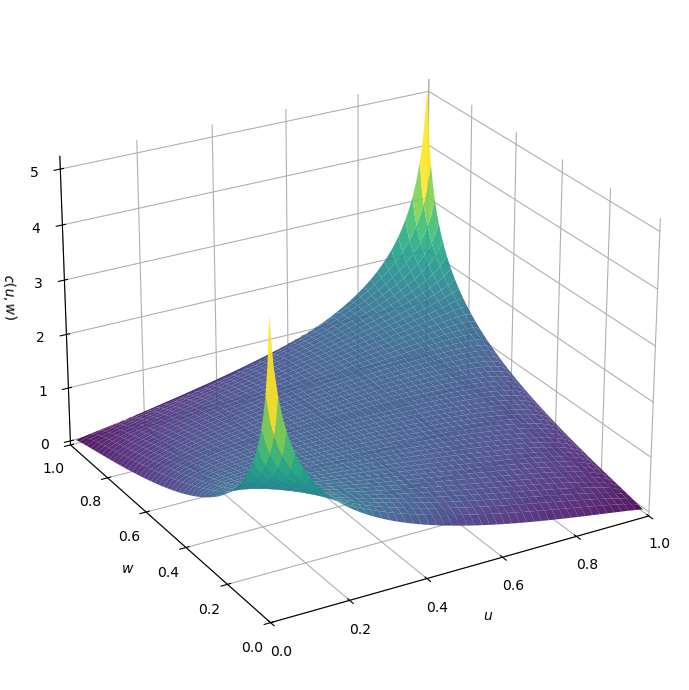

In [4]:
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

surf = ax.plot_surface(U, W, f, cmap="viridis", edgecolor="none", alpha=0.9)

ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False
ax.xaxis.pane.set_edgecolor("white")
ax.yaxis.pane.set_edgecolor("white")
ax.zaxis.pane.set_edgecolor("white")

ax.set_xlabel("$u$")
ax.set_ylabel("$w$")
ax.set_zlabel("$c(u,w)$")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.view_init(elev=25, azim=240)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "gaussian_copula_density.png"),
            dpi=200, transparent=True, bbox_inches="tight")
plt.show()

In [5]:
from matplotlib.animation import FuncAnimation, PillowWriter

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(U, W, f, cmap="viridis", edgecolor="none", alpha=0.9)

ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False
ax.xaxis.pane.set_edgecolor("white")
ax.yaxis.pane.set_edgecolor("white")
ax.zaxis.pane.set_edgecolor("white")

ax.set_xlabel("$u$")
ax.set_ylabel("$w$")
ax.set_zlabel("$c(u,w)$")
ax.set_title(f"Gaussian Copula Density (rho = {RHO})", fontsize=13)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

def update(angle):
    ax.view_init(elev=25, azim=angle)
    return fig,

n_frames = 72
anim = FuncAnimation(fig, update, frames=np.linspace(0, 360, n_frames, endpoint=False), interval=80)

writer = PillowWriter(fps=15)
anim.save(os.path.join(OUTPUT_DIR, "gaussian_copula_density_rotation.gif"), writer=writer, dpi=120)
plt.close(fig)